In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
plt.rcParams.update({
    "axes.labelsize": 12,     
    "axes.titlesize": 14, 
    "xtick.labelsize": 12,
    "ytick.labelsize": 12, 
    "legend.fontsize": 8,
})

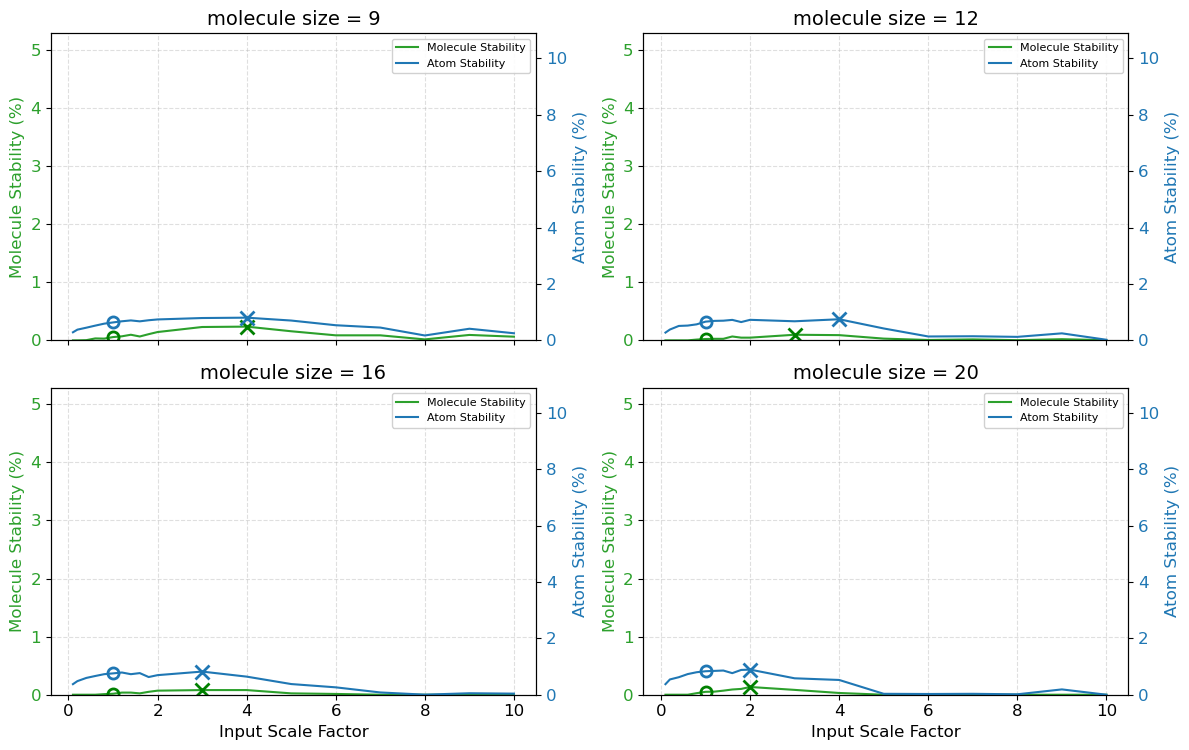

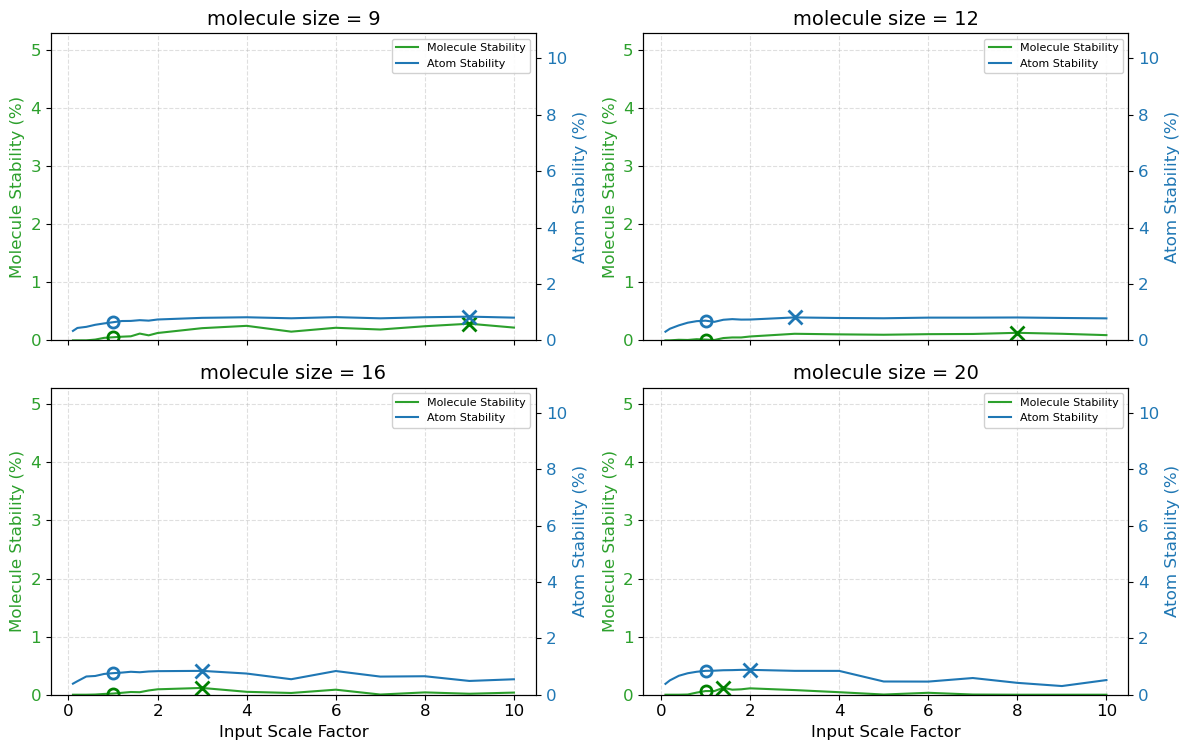

In [3]:
df = pd.read_csv("input_scaling_evaluation_log_rq1.csv")  # replace with your actual CSV filename

grouped = (
    df.groupby(["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule"])
    .agg({"atm_stable": "mean", "mol_stable": "mean"})
    .reset_index()
)

print(grouped.groupby(["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule"]))

mol_min, mol_max = grouped["mol_stable"].min(), grouped["mol_stable"].max()
atm_min, atm_max = grouped["atm_stable"].min(), grouped["atm_stable"].max()

noise_schedules = grouped["diffusion_noise_schedule"].unique()
filter_values = sorted(grouped["filter_n_atoms"].unique())

for noise_schedule, schedule_df in grouped.groupby("diffusion_noise_schedule"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, n_atoms in enumerate(filter_values):
        ax_left = axes[i]
        sub_df = schedule_df[schedule_df["filter_n_atoms"] == n_atoms].copy()

        sub_df = sub_df.sort_values("input_scale_factor").reset_index(drop=True)

        x = sub_df["input_scale_factor"].values
        y_mol = sub_df["mol_stable"].values
        y_atm = sub_df["atm_stable"].values

        color_left = "tab:green"
        ax_left.set_title(f"molecule size = {n_atoms}")
        ax_left.plot(x, y_mol, linestyle='-', markersize=6,
                     color=color_left, label="Molecule Stability (mol_stable)")
        ax_left.set_ylabel("Molecule Stability (%)", color=color_left)
        ax_left.tick_params(axis='y', labelcolor=color_left)
        ax_left.set_ylim(mol_min, mol_max+5)
        ax_left.grid(True, linestyle='--', alpha=0.4)

        idx_mol_max = int(np.nanargmax(y_mol))
        ax_left.plot(x[idx_mol_max], y_mol[idx_mol_max],
                     marker='x', markersize=10, markeredgewidth=2,
                     color='green', zorder=5, label="Max mol_stable")

        ax_right = ax_left.twinx()
        color_right = "tab:blue"
        ax_right.plot(x, y_atm, linestyle='-', markersize=6,
                      color=color_right, label="Atom Stability (atm_stable)")
        ax_right.set_ylabel("Atom Stability (%)", color=color_right)
        ax_right.tick_params(axis='y', labelcolor=color_right)
        ax_right.set_ylim(atm_min, atm_max+10)

        # Mark mol_stable and atm_stable at scale factor 1.0
        if 1.0 in sub_df["input_scale_factor"].values:
            idx_1_mol = np.where(sub_df["input_scale_factor"].values == 1.0)[0][0]
            ax_left.plot(x[idx_1_mol], y_mol[idx_1_mol], marker='o', markersize=8, 
                         markeredgewidth=2, markeredgecolor='green', markerfacecolor='none', zorder=6)
            idx_1_atom = np.where(sub_df["input_scale_factor"].values == 1.0)[0][0]
            ax_right.plot(x[idx_1_atom], y_atm[idx_1_atom], marker='o', markersize=8,
                  markeredgewidth=2, markeredgecolor='tab:blue', markerfacecolor='none', zorder=6)

        idx_atm_max = int(np.nanargmax(y_atm))
        ax_right.plot(x[idx_atm_max], y_atm[idx_atm_max],
                      marker='x', markersize=10, markeredgewidth=2,
                      color=color_right, zorder=5, label="Max atm_stable")

        if i >= 2:
           ax_left.set_xlabel("Input Scale Factor")

        handles = [
            Line2D([0], [0], color=color_left, markersize=6, label="Molecule Stability"),
            Line2D([0], [0], color=color_right, markersize=6, label="Atom Stability"),
        ]
        ax_left.legend(handles=handles, loc="upper right", framealpha=0.9)

    # plt.suptitle(f"Diffusion Noise Schedule: {noise_schedule}", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


[ 9 12 16 20]
[4. 3. 3. 2.]


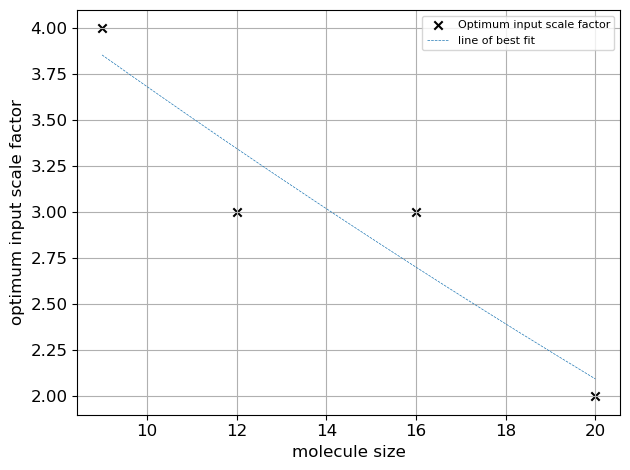

[ 9 12 16 20]
[9.  8.  3.  1.4]


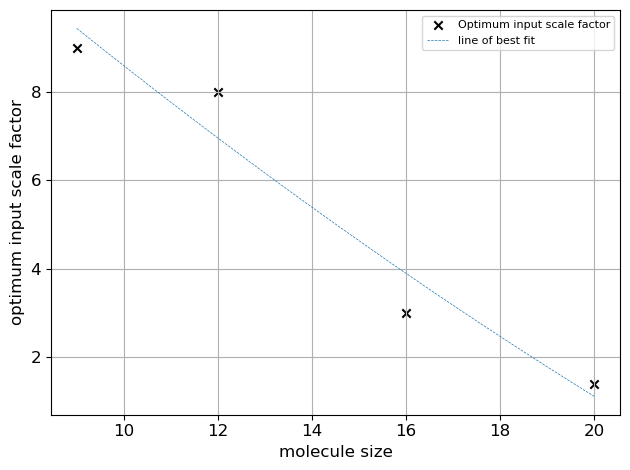

In [5]:
# Load CSV
df = pd.read_csv("input_scaling_evaluation_log_rq1.csv")

# Average atm_stable and mol_stable over seeds
avg_df = (
    df.groupby(["diffusion_noise_schedule", "filter_n_atoms", "input_scale_factor"], as_index=False)
      .agg({"atm_stable": "mean", "mol_stable": "mean"})
)

# Find the best (highest mol_stable) input_scale_factor for each schedule + atom count
opt_df = avg_df.loc[
    avg_df.groupby(["diffusion_noise_schedule", "filter_n_atoms"])["mol_stable"].idxmax()
]

# Plot one graph per diffusion_noise_schedule
for schedule, sub in opt_df.groupby("diffusion_noise_schedule"):
    sub = sub.sort_values("filter_n_atoms")
    x = sub["filter_n_atoms"].values
    y = sub["input_scale_factor"].values
    print(x)
    print(y)

    # Fit quadratic regression (degree = 2)
    coeffs = np.polyfit(x, y, 2)
    curve = np.poly1d(coeffs)

    # Smooth curve points
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = curve(x_fit)

    # Plot points and curve
    plt.figure()
    plt.scatter(x, y, color="black", label="Optimum input scale factor", marker='x')
    plt.plot(x_fit, y_fit, linestyle="--", label="line of best fit", linewidth=0.5)

    # plt.title(f"Optimum Input Scale Factor — {schedule}")
    plt.xlabel("molecule size")
    plt.ylabel("optimum input scale factor")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
